In [ ]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Convolutional Neural Network (CNN)

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://www.tensorflow.org/tutorials/images/cnn">
    <img src="https://www.tensorflow.org/images/tf_logo_32px.png" />
    View on TensorFlow.org</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/images/cnn.ipynb">
    <img src="https://www.tensorflow.org/images/colab_logo_32px.png" />
    Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/tensorflow/docs/blob/master/site/en/tutorials/images/cnn.ipynb">
    <img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />
    View source on GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/docs/site/en/tutorials/images/cnn.ipynb"><img src="https://www.tensorflow.org/images/download_logo_32px.png" />Download notebook</a>
  </td>
</table>

This tutorial demonstrates training a simple [Convolutional Neural Network](https://developers.google.com/machine-learning/glossary/#convolutional_neural_network) (CNN) to classify [CIFAR images](https://www.cs.toronto.edu/~kriz/cifar.html). Because this tutorial uses the [Keras Sequential API](https://www.tensorflow.org/guide/keras/overview), creating and training your model will take just a few lines of code.


### Import TensorFlow

In [25]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

# Create CIFAR-10 dataset

For this project, I created a modified dataset by selecting three classes: airplanes, automobiles, and birds. This allows the CNN tutorial to be tested with a different input dataset while maintaining the original 32 × 32 RGB image format.

In [26]:
# Load CIFAR-10
(x, y), (x_test_original, y_test_original) = tf.keras.datasets.cifar10.load_data()

# 3 classes: airplane, automobile, bird
classes = [0, 1, 2]

# Select only those classes
train_mask = np.isin(y.flatten(), classes)
test_mask = np.isin(y_test_original.flatten(), classes)

x_train = x[train_mask]
y_train = y[train_mask].flatten()

x_test = x_test_original[test_mask]
y_test = y_test_original[test_mask].flatten()

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)
print("Classes:", classes)

Training images: (15000, 32, 32, 3)
Testing images: (3000, 32, 32, 3)
Classes: [0, 1, 2]






# Build the CNN and Complie the model





The CNN is built using several layers. Convolutional layers detect features in the images, while max-pooling layers reduce the size of the feature maps. The Flatten layer converts the extracted features into a format that can be used by the dense layers.
The final dense layer contains three outputs because the modified dataset contains three image classes.

In [27]:
# Normalize the image data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Build the CNN
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(3, activation="softmax")
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Show the model structure
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,115 (477.01 KB)

 Trainable params: 122,115 (477.01 KB)

 Non-trainable params: 0 (0.00 B)

# Train the CNN

The CNN is now trained using the training images. Ten epochs are used for this experiment. During training, the model's accuracy and loss are measured using both the training and validation data.

In [28]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.7307 - loss: 0.6295 - val_accuracy: 0.8123 - val_loss: 0.4656
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.8235 - loss: 0.4409 - val_accuracy: 0.8493 - val_loss: 0.3866
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.8550 - loss: 0.3696 - val_accuracy: 0.8123 - val_loss: 0.4612
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.8745 - loss: 0.3223 - val_accuracy: 0.8813 - val_loss: 0.3025
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.8906 - loss: 0.2810 - val_accuracy: 0.8767 - val_loss: 0.3120
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.9043 - loss: 0.2475 - val_accuracy: 0.8903 - val_loss: 0.2953
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 47ms/step - accuracy: 0.9120 - loss: 0.2286 - val_accuracy: 0.8870 - val_loss: 0.3075
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9265 - loss: 0.1965 - 

The CNN achieved a validation accuracy of 89.90% after 10 epochs. This result provides the baseline that will be used to evaluate the refined CNN models.

# Refine the CNN

The first refinement adds data augmentation and a 50% dropout layer. Data augmentation creates variations of training images, while dropout temporarily removes some connections during training to reduce overfitting.

In [29]:

data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

refined_model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(3, activation="softmax")
])

refined_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

refined_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
refined_history = refined_model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.6788 - loss: 0.7493 - val_accuracy: 0.7737 - val_loss: 0.5475
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.7771 - loss: 0.5670 - val_accuracy: 0.8357 - val_loss: 0.4283
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.7989 - loss: 0.5145 - val_accuracy: 0.8260 - val_loss: 0.4330
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - accuracy: 0.8136 - loss: 0.4831 - val_accuracy: 0.8270 - val_loss: 0.4325
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - accuracy: 0.8201 - loss: 0.4631 - val_accuracy: 0.8273 - val_loss: 0.4317
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - accuracy: 0.8309 - loss: 0.4477 - val_accuracy: 0.8613 - val_loss: 0.3497
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step - accuracy: 0.8403 - loss: 0.4199 - val_accuracy: 0.8377 - val_loss: 0.4117
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - accuracy: 0.8468 - loss: 0.4022 - 

The first refined CNN achieved a validation accuracy of 86.83%. This was lower than the original CNN's 89.90%, so this refinement did not improve the model for this dataset.

# Second CNN refeinement

A second refinement was tested by reducing the dropout rate from 50% to 30%. This allows the model to retain more information while still using dropout to reduce overfitting.

In [31]:
# Second refined CNN

better_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(3, activation="softmax")
])

better_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

better_history = better_model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.7139 - loss: 0.6663 - val_accuracy: 0.8177 - val_loss: 0.4545
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 47ms/step - accuracy: 0.8170 - loss: 0.4629 - val_accuracy: 0.8500 - val_loss: 0.3768
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.8561 - loss: 0.3758 - val_accuracy: 0.8633 - val_loss: 0.3524
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.8757 - loss: 0.3282 - val_accuracy: 0.8800 - val_loss: 0.3137
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.8855 - loss: 0.3002 - val_accuracy: 0.8913 - val_loss: 0.2915
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.8984 - loss: 0.2698 - val_accuracy: 0.8867 - val_loss: 0.3090
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.9118 - loss: 0.2391 - val_accuracy: 0.8957 - val_loss: 0.2832
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.9165 - loss: 0.2191 - 

The second refined CNN achieved a validation accuracy of 90.23%. This was higher than the original CNN's 89.90% accuracy and the first refinement's 86.83%. Therefore, the second refinement produced the best result in this experiment.

# Evaluate the model

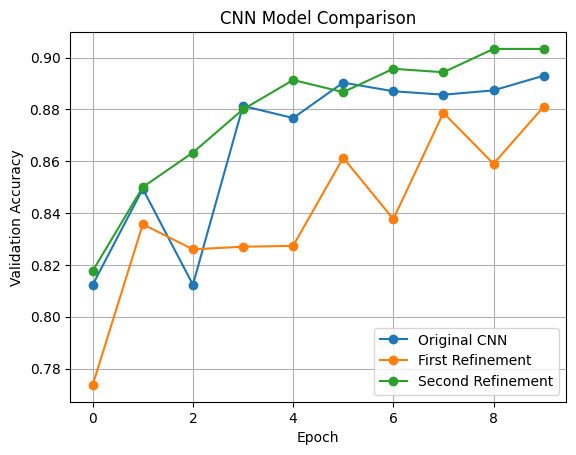

In [32]:
import matplotlib.pyplot as plt

plt.plot(history.history["val_accuracy"], marker="o", label="Original CNN")
plt.plot(refined_history.history["val_accuracy"], marker="o", label="First Refinement")
plt.plot(better_history.history["val_accuracy"], marker="o", label="Second Refinement")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("CNN Model Comparison")
plt.legend()
plt.grid(True)

plt.show()